# **Plotting Seasonal GDR Analysis**


MODELS — significant results (p < 0.05)
  MAM | Neutral (1 of 9 valid):
    CSIRO-Mk3L-1-2        r=-2.510  p=0.0032
  SON | Neutral (2 of 8 valid):
    GISS-E2-R             r=-1.436  p=0.0250
    IPSL-CM5A-LR          r=-1.566  p=0.0265

RECONS — significant results (p < 0.05)
Saved: /home/563/ft3359/FT-Honours/Honours_Paper/Figures/GDR_seasonal_analysis.png


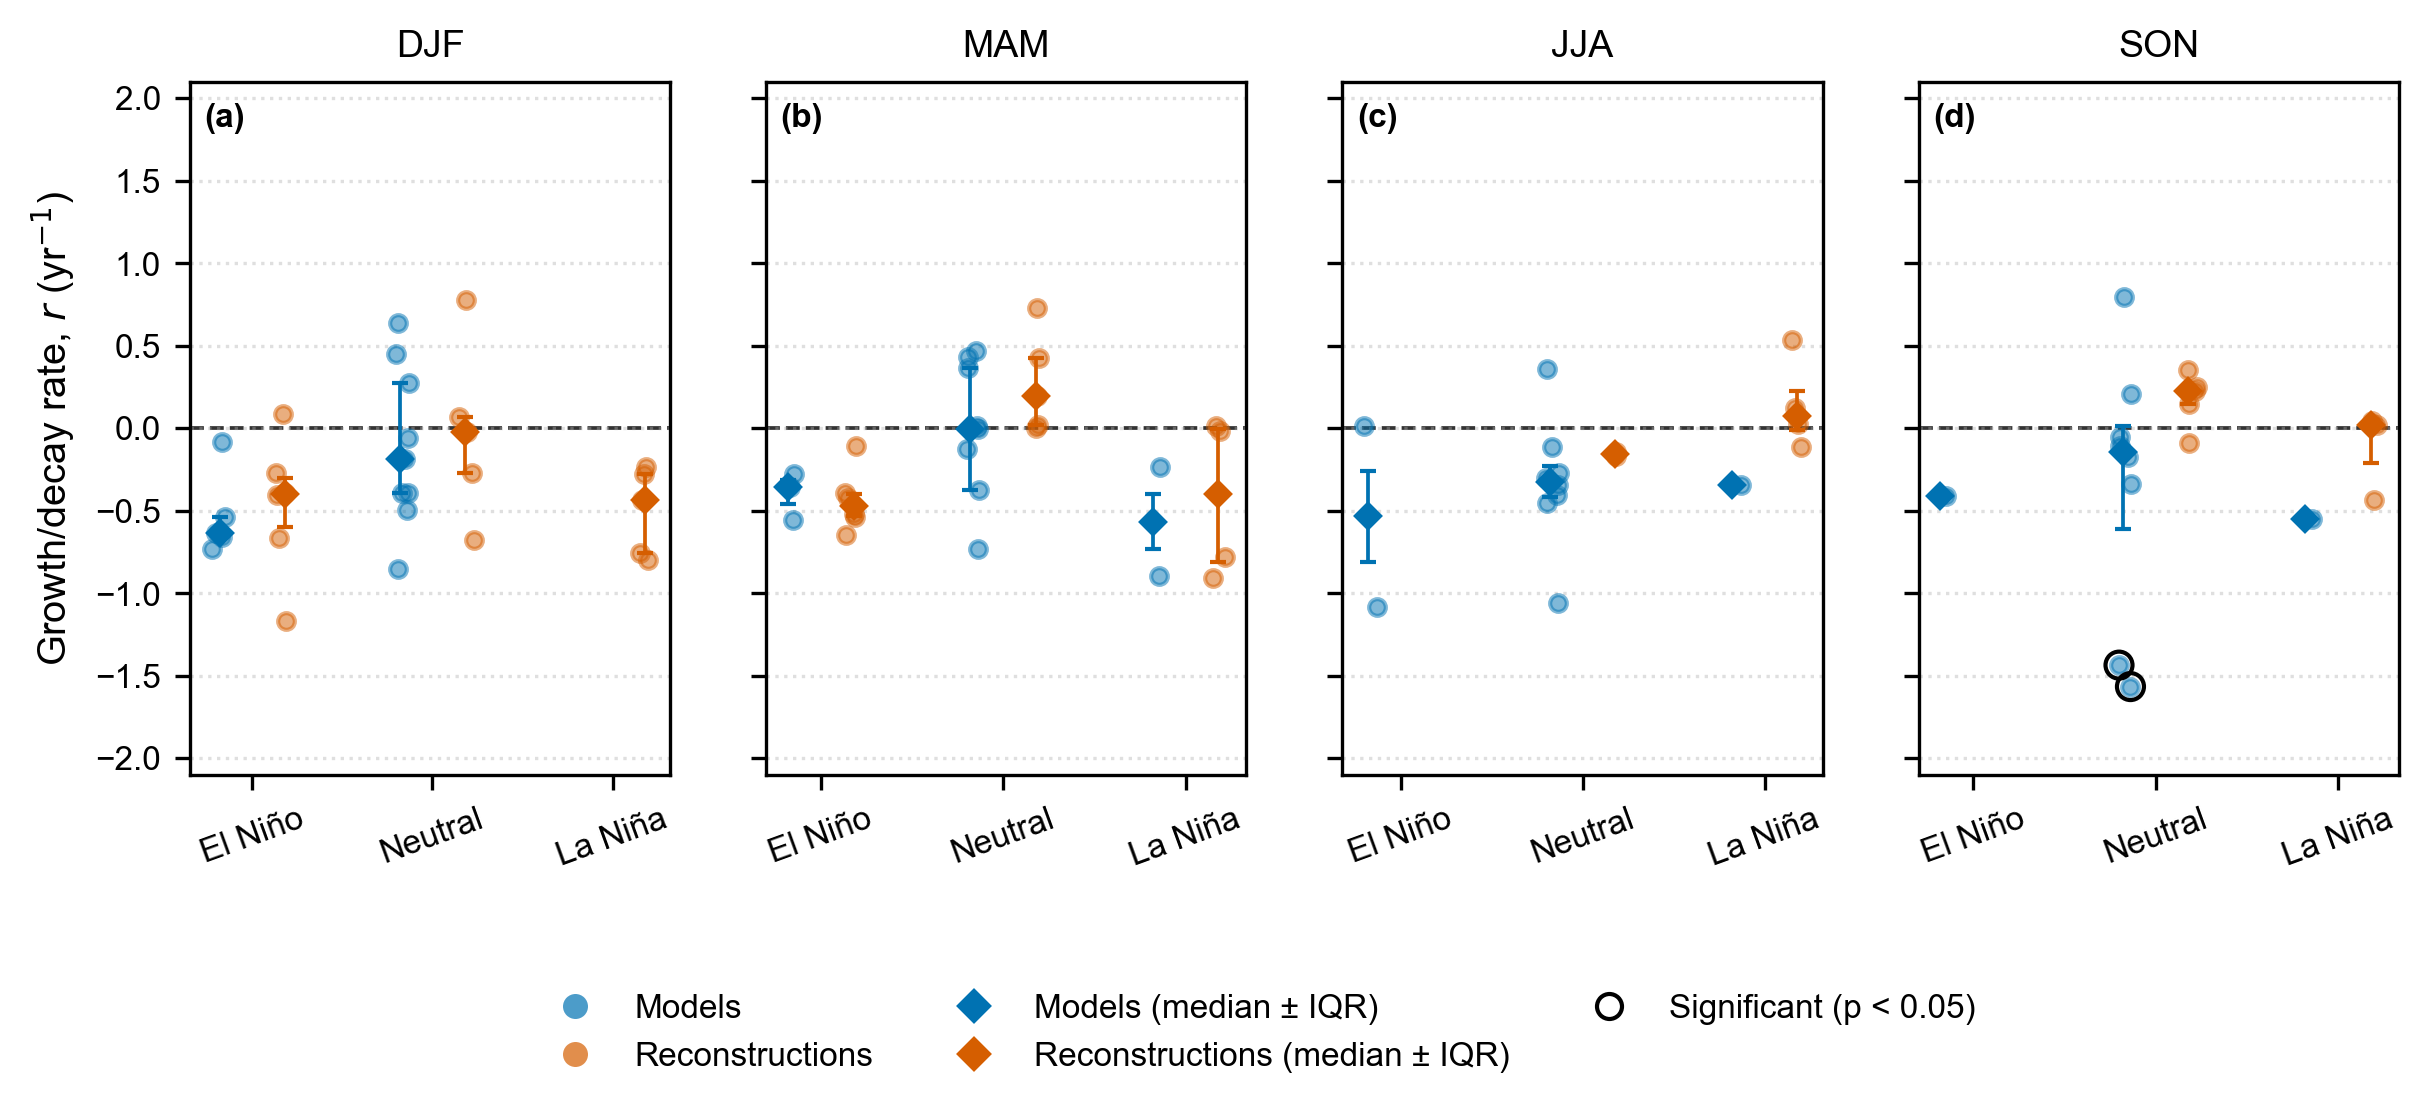

In [1]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D


# FONT
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]


# PATHS (CSV inputs) — per-dataset resolution (one row per model/recon per season x phase bin)

TABLE_DIR = "/home/563/ft3359/FT-Honours/Honours_Paper/GDR/Seasonal_Analysis"
MODEL_CSV = os.path.join(TABLE_DIR, "ENSO-GDR-Models-Seasonal.csv")
RECON_CSV = os.path.join(TABLE_DIR, "ENSO-GDR-Recons-Seasonal.csv")

# Output directory
FIG_OUT = "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/GDR_seasonal_analysis.png"


# SETTINGS
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
PHASE_ORDER  = ["El Niño", "Neutral", "La Niña"]
POOL_SPREAD = "iqr"   # "iqr" or "sd"
MIN_N_FOR_POOL = 1
SIG_LEVEL = 0.05
YLIM = (-2.1, 2.1)
PANEL_LABELS = string.ascii_lowercase  # 'a', 'b', 'c', 'd', ...

# COLOURS
MODEL_COLOR = "#0072B2"
RECON_COLOR = "#D55E00"

# HELPERS

def load_df(path: str, label: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}")

    df = pd.read_csv(path)

    # Normalise column names (mirrors original all_eruptions load_df)
    if "case" in df.columns and "dataset" not in df.columns:
        pass  # case column is fine to keep alongside dataset

    needed = {"dataset", "season", "phase", "N_events", "r_yr1", "tau_yr", "p_value"}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"{label} CSV missing columns: {missing}\nFound: {list(df.columns)}")

    df = df.copy()
    df["dataset"] = df["dataset"].astype(str)
    df["season"] = df["season"].astype(str)
    df["phase"] = df["phase"].astype(str)

    for c in ["N_events", "r_yr1", "tau_yr", "p_value"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df[df["season"].isin(SEASON_ORDER) & df["phase"].isin(PHASE_ORDER)].copy()
    df["season"] = pd.Categorical(df["season"], categories=SEASON_ORDER, ordered=True)
    df["phase"] = pd.Categorical(df["phase"], categories=PHASE_ORDER, ordered=True)
    return df


def wlp_pool(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Median + IQR pooled across datasets (models or reconstructions), per season x phase bin.
    Mirrors the wlp_pool() logic from the original all_eruptions plotting script."""
    rows = []
    for season in SEASON_ORDER:
        for phase in PHASE_ORDER:
            sub = df[(df["season"] == season) & (df["phase"] == phase)]
            vals = sub[value_col].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            n = int(vals.size)

            if n < MIN_N_FOR_POOL:
                rows.append({
                    "season": season, "phase": phase,
                    "pooled_mean": np.nan, "pooled_q25": np.nan,
                    "pooled_q50": np.nan, "pooled_q75": np.nan,
                    "pooled_sd": np.nan, "n_used": n
                })
                continue

            q25, q50, q75 = np.percentile(vals, [25, 50, 75])
            rows.append({
                "season": season, "phase": phase,
                "pooled_mean": float(q50),
                "pooled_q25": float(q25), "pooled_q50": float(q50), "pooled_q75": float(q75),
                "pooled_sd": float(np.std(vals, ddof=1)) if n >= 2 else 0.0,
                "n_used": n
            })

    out = pd.DataFrame(rows)
    out["season"] = pd.Categorical(out["season"], categories=SEASON_ORDER, ordered=True)
    out["phase"] = pd.Categorical(out["phase"], categories=PHASE_ORDER, ordered=True)
    return out


def spread_to_err(row):
    """Mirrors spread_to_err() from the original all_eruptions plotting script."""
    m = row["pooled_mean"]
    if POOL_SPREAD.lower() == "sd":
        sd = row["pooled_sd"]
        lo = hi = sd if np.isfinite(sd) else np.nan
    else:
        lo = m - row["pooled_q25"]
        hi = row["pooled_q75"] - m
    lo = max(lo, 0.0) if np.isfinite(lo) else np.nan
    hi = max(hi, 0.0) if np.isfinite(hi) else np.nan
    return lo, hi


def jitter(x, n, width=0.05, seed=0):
    rng = np.random.default_rng(seed)
    return x + rng.uniform(-width, width, size=n)


def print_significance_summary(title, df):
    print(f"\n{title} — significant results (p < {SIG_LEVEL})")
    for season in SEASON_ORDER:
        for phase in PHASE_ORDER:
            sub = df[(df["season"] == season) & (df["phase"] == phase)]
            sig = sub[sub["p_value"] < SIG_LEVEL]
            valid = sub["p_value"].notna().sum()
            if valid == 0:
                continue
            if not sig.empty:
                print(f"  {season} | {phase} ({len(sig)} of {valid} valid):")
                for _, row in sig.iterrows():
                    print(f"    {row['dataset']:20s}  r={row['r_yr1']:.3f}  p={row['p_value']:.4f}")


# LOAD DATA

df_m = load_df(MODEL_CSV, "MODELS")
df_r = load_df(RECON_CSV, "RECONS")

pool_m = wlp_pool(df_m, "r_yr1")
pool_r = wlp_pool(df_r, "r_yr1")

print_significance_summary("MODELS", df_m)
print_significance_summary("RECONS", df_r)


# PLOT — faceted by season, phase on x-axis, per-dataset scatter + pooled median±IQR diamonds
# (same visual language as the original all_eruptions_analysis figure)

fig, axes = plt.subplots(1, len(SEASON_ORDER), figsize=(9.5, 3.0), dpi=300, sharey=True)
x = np.arange(len(PHASE_ORDER))

for i, (ax, season) in enumerate(zip(axes, SEASON_ORDER)):
    for j, phase in enumerate(PHASE_ORDER):
        subm = df_m[(df_m["season"] == season) & (df_m["phase"] == phase)]
        subr = df_r[(df_r["season"] == season) & (df_r["phase"] == phase)]

        xm = jitter(np.full(len(subm), j - 0.18), len(subm), seed=100 + j)
        xr_ = jitter(np.full(len(subr), j + 0.18), len(subr), seed=200 + j)

        # Base points (scaled down slightly from original s=28, alpha=0.5)
        ax.scatter(xm, subm["r_yr1"], s=16, alpha=0.5, color=MODEL_COLOR, zorder=2)
        ax.scatter(xr_, subr["r_yr1"], s=16, alpha=0.5, color=RECON_COLOR, zorder=2)

        # Significant points: black ring overlay (scaled down from original s=70)
        sigm = subm["p_value"] < SIG_LEVEL
        sigr = subr["p_value"] < SIG_LEVEL
        if sigm.any():
            ax.scatter(xm[sigm.to_numpy()], subm.loc[sigm, "r_yr1"], s=42,
                       facecolors="none", edgecolors="black", linewidths=1.0, zorder=4)
        if sigr.any():
            ax.scatter(xr_[sigr.to_numpy()], subr.loc[sigr, "r_yr1"], s=42,
                       facecolors="none", edgecolors="black", linewidths=1.0, zorder=4)

    # pooled WLP medians + spread bars (scaled down from original fmt="D", capsize=3, markersize=6)
    pm_season = pool_m[pool_m["season"] == season].set_index("phase").reindex(PHASE_ORDER)
    pr_season = pool_r[pool_r["season"] == season].set_index("phase").reindex(PHASE_ORDER)

    m_lo = np.array([spread_to_err(pm_season.loc[p])[0] for p in PHASE_ORDER])
    m_hi = np.array([spread_to_err(pm_season.loc[p])[1] for p in PHASE_ORDER])
    r_lo = np.array([spread_to_err(pr_season.loc[p])[0] for p in PHASE_ORDER])
    r_hi = np.array([spread_to_err(pr_season.loc[p])[1] for p in PHASE_ORDER])

    ax.errorbar(
        x - 0.18, pm_season["pooled_mean"], yerr=[m_lo, m_hi],
        fmt="D", capsize=2, elinewidth=0.9, markersize=4,
        color=MODEL_COLOR, zorder=5
    )
    ax.errorbar(
        x + 0.18, pr_season["pooled_mean"], yerr=[r_lo, r_hi],
        fmt="D", capsize=2, elinewidth=0.9, markersize=4,
        color=RECON_COLOR, zorder=5
    )

    ax.axhline(0, linewidth=0.9, color="black", linestyle="--", alpha=0.8, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(PHASE_ORDER, fontsize=8, rotation=20)
    ax.set_title(season, fontsize=9)
    ax.set_ylim(*YLIM)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    # Panel label, top-left inside axes (matches Copernicus/CP-style panel lettering)
    ax.text(
        0.03, 0.97, f"({PANEL_LABELS[i]})",
        transform=ax.transAxes,
        fontsize=8, fontweight="bold",
        va="top", ha="left", zorder=6
    )

axes[0].set_ylabel("Growth/decay rate, $r$ (yr$^{-1}$)", fontsize=9.5)
axes[0].tick_params(axis="y", labelsize=8)

# Legend (same construction as original: handles + sig_handle appended)
handles = [
    Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=MODEL_COLOR,
           markeredgecolor="none", markersize=6, alpha=0.7, label="Models"),
    Line2D([0], [0], marker="o", linestyle="None", markerfacecolor=RECON_COLOR,
           markeredgecolor="none", markersize=6, alpha=0.7, label="Reconstructions"),
    Line2D([0], [0], marker="D", linestyle="None", markerfacecolor=MODEL_COLOR,
           markeredgecolor=MODEL_COLOR, markersize=5, label="Models (median ± IQR)"),
    Line2D([0], [0], marker="D", linestyle="None", markerfacecolor=RECON_COLOR,
           markeredgecolor=RECON_COLOR, markersize=5, label="Reconstructions (median ± IQR)"),
]
sig_handle = Line2D(
    [0], [0], marker="o", linestyle="None",
    markerfacecolor="none", markeredgecolor="black",
    markeredgewidth=1.0, markersize=6,
    label=f"Significant (p < {SIG_LEVEL})"
)
handles.append(sig_handle)

fig.legend(
    handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.10),
    ncols=3, fontsize=8, frameon=False
)

os.makedirs(os.path.dirname(FIG_OUT), exist_ok=True)
fig.savefig(FIG_OUT, dpi=300, bbox_inches="tight")
print("Saved:", FIG_OUT)

plt.show()